<a href="https://colab.research.google.com/github/AKakatii-08/Cosmology-Second-project/blob/main/CONTOUR_FOR_SEPARATION_DISTANCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LCDM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.colors import LogNorm

# =========================================================
# Physical Constants
# =========================================================

G = 6.67430e-11          # m^3 kg^-1 s^-2
c = 3e8         # m/s
M_sun = 2e30       # kg
pc = 3.086e16            # meters

# =========================================================
# LCDM Cosmology Parameters
# =========================================================

H0 = 67.4 * 1000 / (3.086e22)   # s^-1
Omega_m = 0.264
Omega_lambda = 0.6847

# =========================================================
# LCDM Luminosity Distance
# =========================================================

def E(z):
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_lambda)

def luminosity_distance(z):

    integral, _ = quad(lambda zp: 1 / E(zp), 0, z)

    dL = (1 + z) * c / H0 * integral

    return dL

In [ ]:
# =========================================================
# Parameter Space
# =========================================================

mass = np.logspace(4, 8, 500)        # Solar masses
redshift = np.linspace(0.01, 20, 500)

M, Z = np.meshgrid(mass, redshift)

# Convert mass to kg
Mkg = M * M_sun


In [ ]:

# =========================================================
# Compute Luminosity Distance Grid
# =========================================================

dL = np.zeros_like(Z)

for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        dL[i, j] = luminosity_distance(Z[i, j])

# =========================================================
# Different Strain Values
# =========================================================

strain_values = [1e-20, 1e-21, 1e-22, 1e-23]


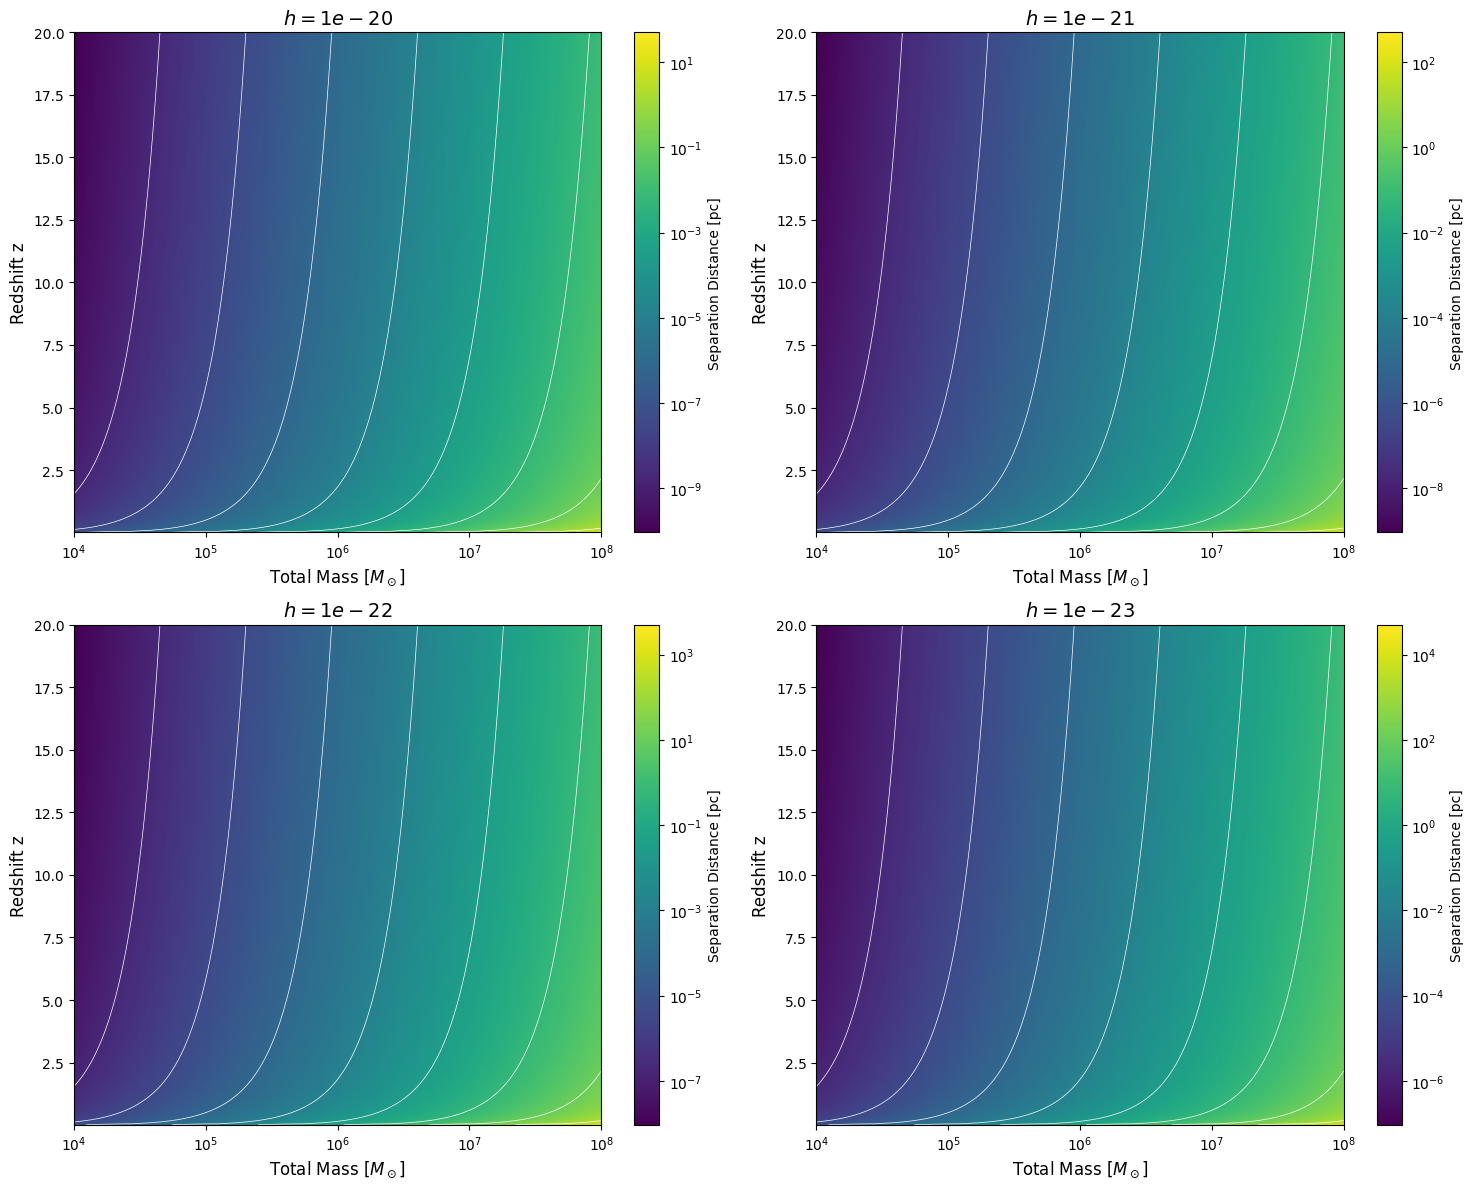

In [ ]:
# =========================================================
# Create 2x2 Quadrant Plot
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes = axes.flatten()

for ax, h in zip(axes, strain_values):

    # Separation distance
    a = (G**2 * Mkg**2) / (c**4 * h * dL)

    # Convert to parsec
    a_pc = a / pc

    # Contour plot

    ax.clabel(lines, fontsize=7)
    mesh = ax.pcolormesh(
        M,
        Z,
        a_pc,
        shading='gouraud',
        norm=LogNorm(),
        cmap='viridis',
    antialiased=True
    )

    # Add contour lines for better visualization
    ax.contour(M, Z, a_pc, levels=np.logspace(np.log10(a_pc.min()), np.log10(a_pc.max()), 10), colors='w', linestyles='-', linewidths=0.5)

    # Axis scaling
    ax.set_xscale("log")

    from matplotlib.ticker import LogLocator, NullLocator

    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_minor_locator(NullLocator())

    # Labels
    ax.set_xlabel(r"Total Mass [$M_\odot$]", fontsize=12)
    ax.set_ylabel("Redshift z", fontsize=12)

    # Title
    ax.set_title(rf"$h = {h:.0e}$", fontsize=14)

    # Colorbar
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("Separation Distance [pc]")

# =========================================================
# Main Title
# =========================================================

#fig.suptitle(
    #"Contour Plot of Binary Separation Distance\n"
   # r"$a = \frac{G^2 M_{tot}^2}{c^4 h d_L(z)}",
   # fontsize=18)

plt.tight_layout()
plt.savefig('LCDM.png', dpi=300)
plt.show()

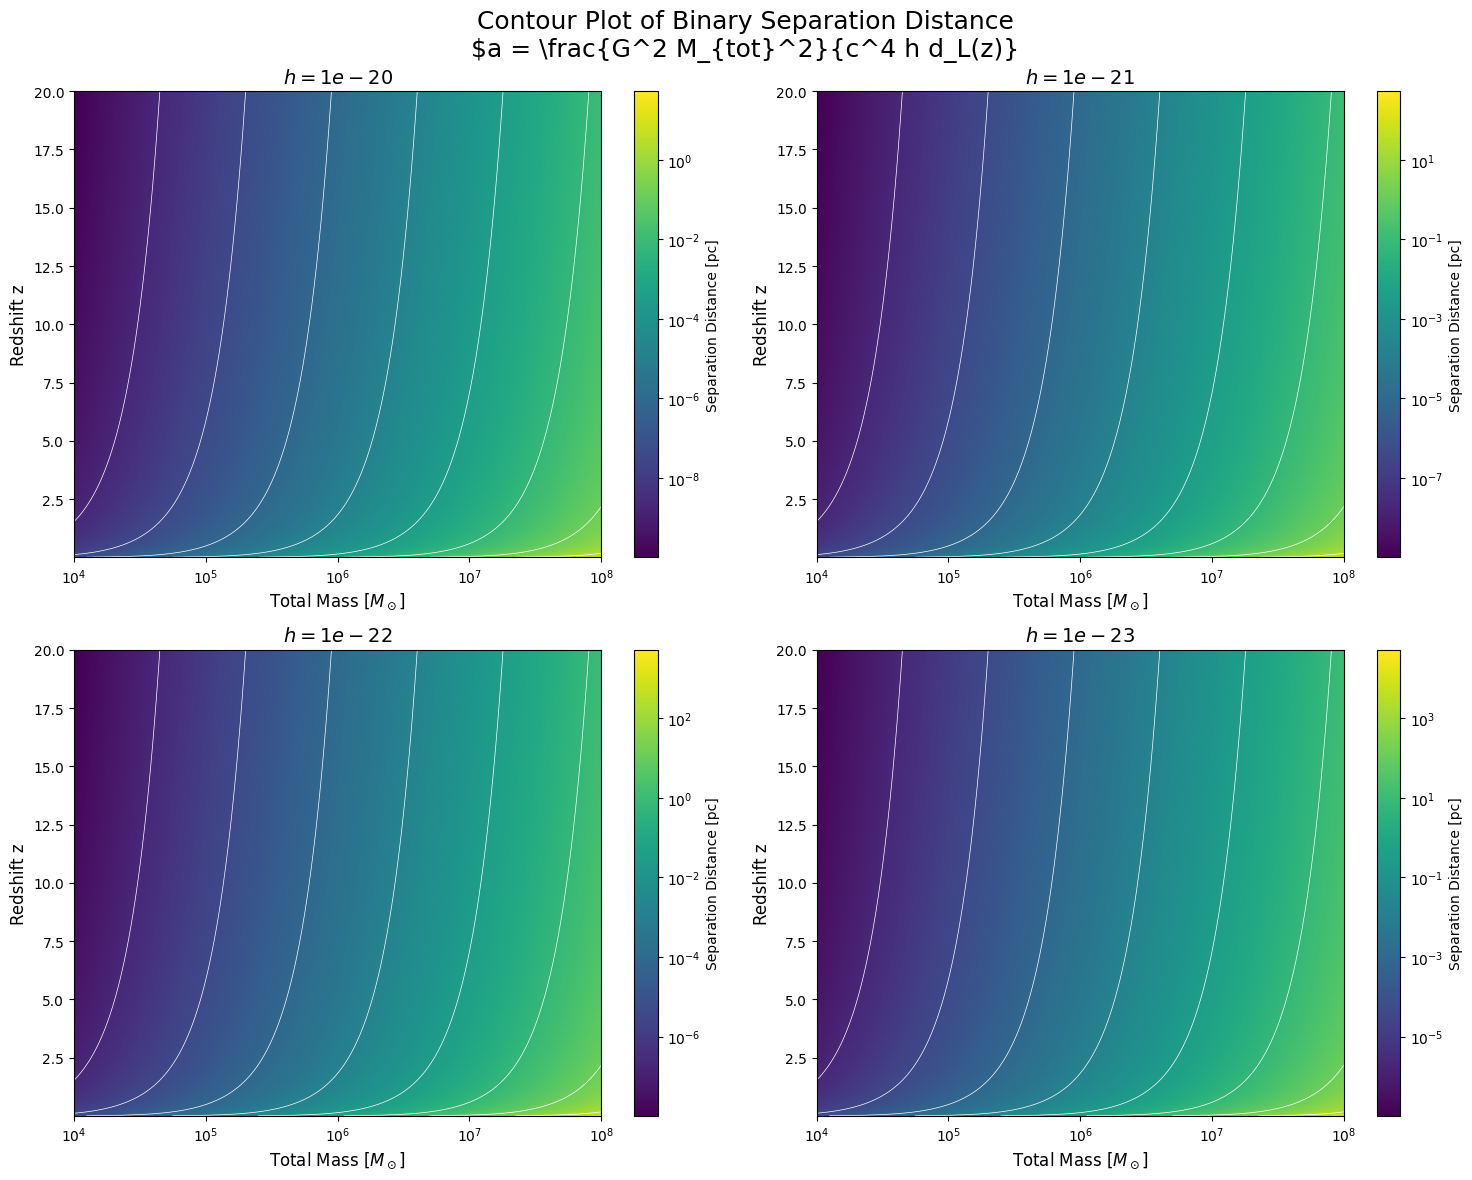

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.colors import LogNorm

# =========================================================
# Physical Constants
# =========================================================

G = 6.67430e-11          # m^3 kg^-1 s^-2
c = 2.99792458e8         # m/s
M_sun = 1.98847e30       # kg
pc = 3.086e16            # meters

# =========================================================
# LCDM Cosmology Parameters
# =========================================================

H0 = 70 * 1000 / (3.086e22)   # s^-1
Omega_m = 0.3
Omega_lambda = 0.7

# =========================================================
# LCDM Luminosity Distance
# =========================================================

def E(z):
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_lambda)

def luminosity_distance(z):

    integral, _ = quad(lambda zp: 1 / E(zp), 0, z)

    dL = (1 + z) * c / H0 * integral

    return dL

# =========================================================
# Parameter Space
# =========================================================

mass = np.logspace(4, 8, 800)        # Solar masses
redshift = np.linspace(0.01, 20, 800)

M, Z = np.meshgrid(mass, redshift)

# Convert mass to kg
Mkg = M * M_sun

# =========================================================
# Compute Luminosity Distance Grid
# =========================================================

dL = np.zeros_like(Z)

for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        dL[i, j] = luminosity_distance(Z[i, j])

# =========================================================
# Different Strain Values
# =========================================================

strain_values = [1e-20, 1e-21, 1e-22, 1e-23]

# =========================================================
# Create 2x2 Quadrant Plot
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes = axes.flatten()

for ax, h in zip(axes, strain_values):

    # Separation distance
    a = (G**2 * Mkg**2) / (c**4 * h * dL)

    # Convert to parsec
    a_pc = a / pc

    # Contour plot
    mesh = ax.pcolormesh(
        M,
        Z,
        a_pc,
        shading='gouraud',
        norm=LogNorm(),
        cmap='viridis',
    antialiased=True
    )

    # Add contour lines for better visualization
    ax.contour(M, Z, a_pc, levels=np.logspace(np.log10(a_pc.min()), np.log10(a_pc.max()), 10), colors='w', linestyles='-', linewidths=0.5)

    # Axis scaling
    ax.set_xscale("log")

    from matplotlib.ticker import LogLocator, NullLocator

    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_minor_locator(NullLocator())

    # Labels
    ax.set_xlabel(r"Total Mass [$M_\odot$]", fontsize=12)
    ax.set_ylabel("Redshift z", fontsize=12)

    # Title
    ax.set_title(rf"$h = {h:.0e}$", fontsize=14)

    # Colorbar
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("Separation Distance [pc]")

# =========================================================
# Main Title
# =========================================================

fig.suptitle(
    "Contour Plot of Binary Separation Distance\n"
    r"$a = \frac{G^2 M_{tot}^2}{c^4 h d_L(z)}",
    fontsize=18
)

plt.tight_layout()

plt.show()

WCDM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, NullLocator

# =========================================================
# Physical Constants
# =========================================================

G = 6.67430e-11          # m^3 kg^-1 s^-2
c = 3e8         # m/s
M_sun = 2e30       # kg
pc = 3.086e16            # meters

In [ ]:

# =========================================================
# Cosmological Parameters
# =========================================================

H0 = 71.1 * 1000 / (3.086e22)   # s^-1
Omega_m = 0.264
Omega_de = 0.736

# =========================================================
# Fixed w value
# =========================================================

w = -0.8

# =========================================================
# wCDM Expansion Function
# =========================================================

def E_wCDM(z):

    return np.sqrt(
        Omega_m * (1 + z)**3 +
        Omega_de * (1 + z)**(3 * (1 + w))
    )

# =========================================================
# Luminosity Distance
# =========================================================

def luminosity_distance(z):

    integral, _ = quad(
        lambda zp: 1 / E_wCDM(zp),
        0,
        z
    )

    dL = (1 + z) * c / H0 * integral

    return dL




In [ ]:
# =========================================================
# Parameter Space
# =========================================================

mass = np.logspace(4, 8, 600)
redshift = np.linspace(0.01, 20, 600)

M, Z = np.meshgrid(mass, redshift)

# Convert mass to kg
Mkg = M * M_sun

# =========================================================
# Compute Luminosity Distance Grid
# =========================================================

dL = np.zeros_like(Z)

for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        dL[i, j] = luminosity_distance(Z[i, j])


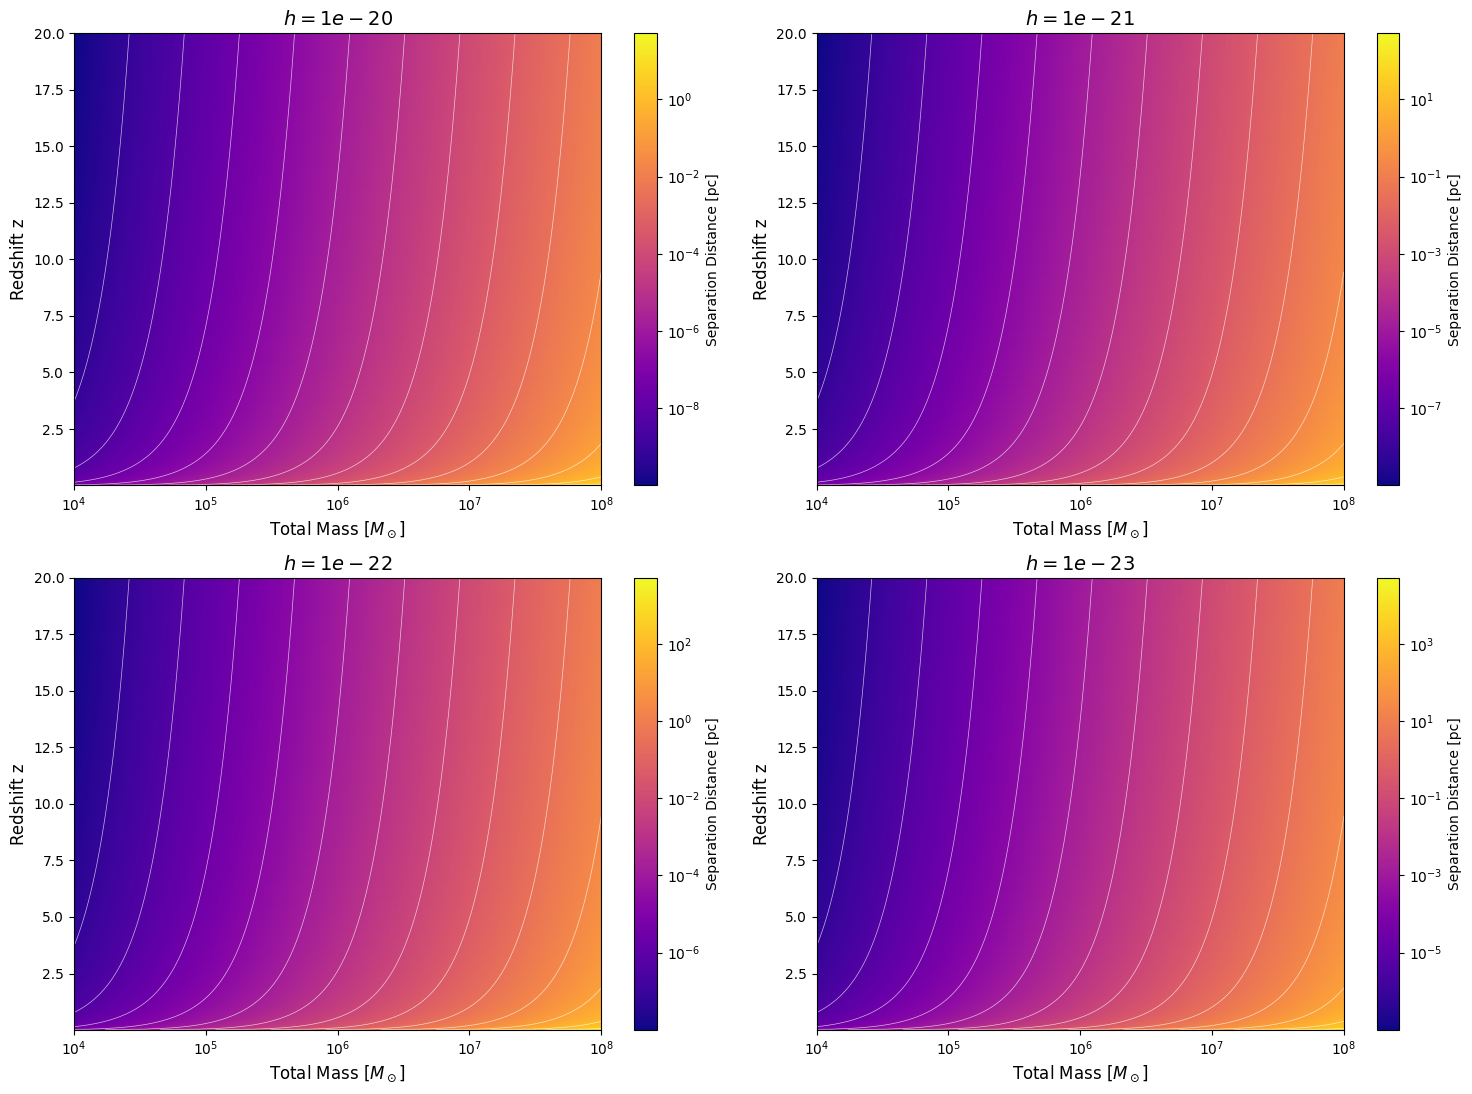

In [ ]:
# =========================================================
# Different Strain Values
# =========================================================

strain_values = [1e-20, 1e-21, 1e-22, 1e-23]

# =========================================================
# Create 2x2 Quadrant Figure
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes = axes.flatten()

# =========================================================
# Main Loop
# =========================================================

for ax, h in zip(axes, strain_values):

    # =====================================================
    # Separation Distance
    # =====================================================

    a = (G**2 * Mkg**2) / (c**4 * h * dL)

    # Convert to parsec
    a_pc = a / pc

    # =====================================================
    # Filled Contours (Background)
    # =====================================================
    mesh = ax.pcolormesh(
        M,
        Z,
        a_pc,
        shading='gouraud',
        norm=LogNorm(),
        cmap='plasma',
        antialiased=True
    )

    # =====================================================
    # White Contour Lines (Overlaid)
    # =====================================================

    lines = ax.contour(
        M,
        Z,
        a_pc,
        levels=np.logspace(np.log10(a_pc.min()), np.log10(a_pc.max()), 15),
        colors='white',
        linewidths=0.5,
        alpha=0.7
    )

    # Add labels to the contour lines
    #ax.clabel(lines, fontsize=8, inline=True, fmt='%.1e')

    # =====================================================
    # Logarithmic x-axis
    # =====================================================

    ax.set_xscale("log")

    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_minor_locator(NullLocator())

    # =====================================================
    # Labels
    # =====================================================

    ax.set_xlabel(r"Total Mass [$M_\odot$]", fontsize=12)
    ax.set_ylabel("Redshift z", fontsize=12)

    # =====================================================
    # Title
    # =====================================================

    ax.set_title(
        rf"$h = {h:.0e}$",
        fontsize=14
    )

    # =====================================================
    # Colorbar
    # =====================================================

    cbar = fig.colorbar(mesh, ax=ax)

    cbar.set_label(
        "Separation Distance [pc]",
        fontsize=10
    )
    # =========================================================
# Main Title
# =========================================================

#fig.suptitle(f"wCDM Model Separation Distance (w={w})", fontsize=18)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# =========================================================
# Save Figure
# =========================================================

plt.savefig(
    "wCDM_contour_quadrant.png",
    bbox_inches='tight'
)

plt.show()


DDE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, NullLocator

# =========================================================
# Physical Constants
# =========================================================



# =========================================================
# Cosmological Parameters
# =========================================================

H0 = 67.22 * 1000 / (3.086e22)   # s^-1
Omega_m = 0.3161
Omega_de = 1-Omega_m

# =========================================================
# DDE Parameters (CPL Parameterization)
# =========================================================

w0 = -0.726
wa = -1.05

# =========================================================
# DDE Expansion Function
# =========================================================

def E_DDE(z):

    dark_energy_term = (
        (1 + z)**(3 * (1 + w0 + wa))
        * np.exp(-3 * wa * z / (1 + z))
    )

    return np.sqrt(
        Omega_m * (1 + z)**3 +
        Omega_de * dark_energy_term
    )

# =========================================================
# Luminosity Distance
# =========================================================

def luminosity_distance(z):

    integral, _ = quad(
        lambda zp: 1 / E_DDE(zp),
        0,
        z
    )

    dL = (1 + z) * c / H0 * integral

    return dL

# =========================================================
# Parameter Space
# =========================================================

mass = np.logspace(4, 8, 700)
redshift = np.linspace(0.01, 20, 700)

M, Z = np.meshgrid(mass, redshift)

# Convert mass to kg
Mkg = M * M_sun

# =========================================================
# Compute Luminosity Distance Grid
# =========================================================

print("Computing luminosity distance grid...")

dL_1D = np.array([
    luminosity_distance(z)
    for z in redshift
])



plt.tight_layout()

# =========================================================
# Save Figure
# =========================================================

plt.savefig(
    "DDE_contour_quadrant.pdf",
    bbox_inches='tight'
)

plt.show()

Computing luminosity distance grid...


<Figure size 640x480 with 0 Axes>

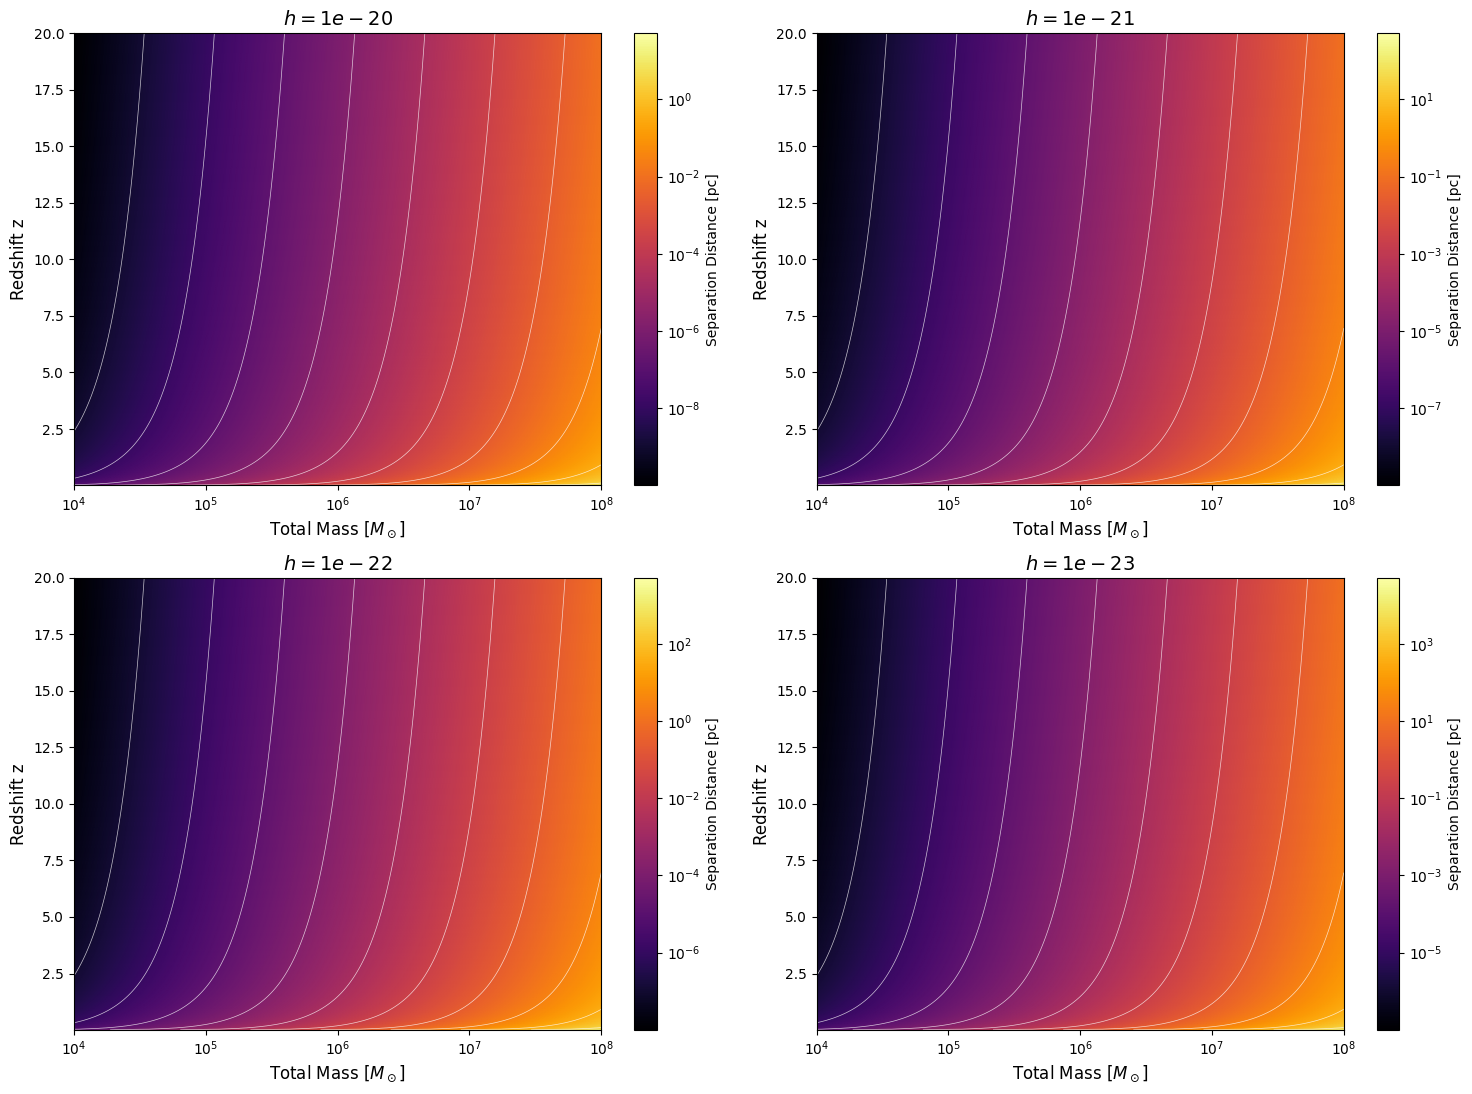

In [ ]:
strain_values = [1e-20, 1e-21, 1e-22, 1e-23]

# =========================================================
# Create 2x2 Quadrant Figure
# =========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 12)
)

axes = axes.flatten()

# =========================================================
# Main Loop
# =========================================================

for ax, h in zip(axes, strain_values):

    # =====================================================
    # Separation Distance
    # =====================================================

    a = (G**2 * Mkg**2) / (c**4 * h * dL)

    # Convert to parsec
    a_pc = a / pc

    # =====================================================
    # Smooth Color Background
    # =====================================================

    mesh = ax.pcolormesh(
        M,
        Z,
        a_pc,
        shading='gouraud',
        norm=LogNorm(),
        cmap='inferno',
        antialiased=True
    )

    # =====================================================
    # Smooth Contour Lines
    # =====================================================

    contour_levels = np.logspace(
        np.log10(a_pc.min()),
        np.log10(a_pc.max()),
        12
    )

    lines = ax.contour(
        M,
        Z,
        a_pc,
        levels=contour_levels,
        colors='white',
        linewidths=0.5,
        alpha=0.75
    )

    # Optional contour labels
    # ax.clabel(lines, fontsize=7, inline=True)

    # =====================================================
    # Logarithmic x-axis
    # =====================================================

    ax.set_xscale("log")

    ax.xaxis.set_major_locator(
        LogLocator(base=10)
    )

    ax.xaxis.set_minor_locator(
        NullLocator()
    )

    # =====================================================
    # Labels
    # =====================================================

    ax.set_xlabel(
        r"Total Mass [$M_\odot$]",
        fontsize=12
    )

    ax.set_ylabel(
        "Redshift z",
        fontsize=12
    )

    # =====================================================
    # Title
    # =====================================================

    ax.set_title(
        rf"$h = {h:.0e}$",
        fontsize=14
    )

    # =====================================================
    # Colorbar
    # =====================================================

    cbar = fig.colorbar(
        mesh,
        ax=ax
    )

    cbar.set_label(
        "Separation Distance [pc]",
        fontsize=10
    )

# =========================================================
# Main Title
# =========================================================


plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# =========================================================
# Save Figure
# =========================================================

plt.savefig(
    "DDE_smooth_contour_quadrant.png",
    bbox_inches='tight',
    dpi=300
)

plt.show()

BRANE WORLD

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, NullLocator

# =========================================================
# Physical Constants
# =========================================================



# Braneworld Parameters
# =========================================================

H0_km = 69.08

# Convert H0 to SI units
H0 = H0_km * 1000 / (3.086e22)

Om = 0.3
Ol = 0.3
Oc = 1.0
Olb = 1e5

# =========================================================
# Braneworld Hubble Function
# =========================================================

def H_Braneworld(z):

    term1 = (
        Om * (1 + z)**3
        + 2 * np.sqrt(Ol * Olb)
    )

    term2 = (
        2 * np.sqrt(
            Ol * (
                Olb +
                Oc * (1 + z)**4
            )
        )
    )

    return H0 * np.sqrt(term1 - term2)

# =========================================================
# Dimensionless Expansion Function
# =========================================================

def E_Braneworld(z):

    return H_Braneworld(z) / H0

# =========================================================
# Luminosity Distance
# =========================================================

def luminosity_distance(z):

    integral, _ = quad(
        lambda zp: 1 / E_Braneworld(zp),
        0,
        z
    )

    dL = (1 + z) * c / H0 * integral

    return dL

# =========================================================
# Parameter Space
# =========================================================

mass = np.logspace(4, 8, 1000)
redshift = np.linspace(0.01, 20, 1000)

M, Z = np.meshgrid(mass, redshift)

# =========================================================
# Convert Mass to kg
# =========================================================

Mkg = M * M_sun

# =========================================================
# Compute Luminosity Distance Grid
# =========================================================

print("Computing luminosity distance grid...")

dL_1D = np.array([
    luminosity_distance(z)
    for z in redshift
])



Computing luminosity distance grid...


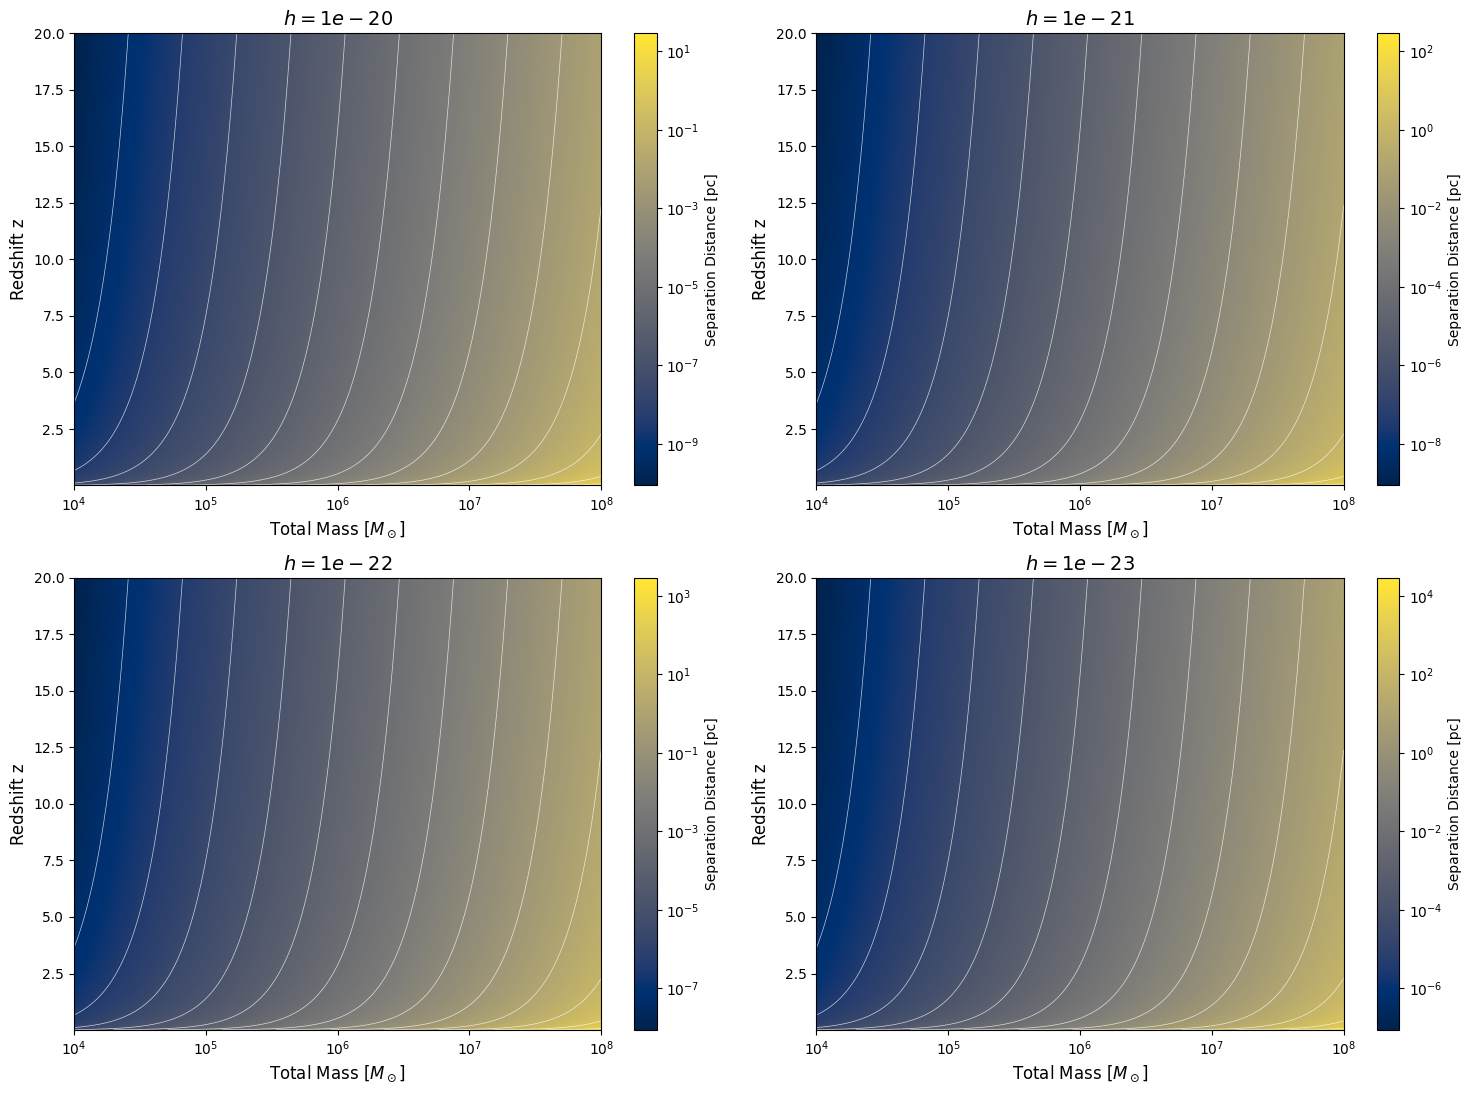

In [57]:
# Expand into 2D grid
dL = np.tile(
    dL_1D[:, np.newaxis],
    (1, len(mass))
)

# =========================================================
# Different Strain Values
# =========================================================

strain_values = [1e-20, 1e-21, 1e-22, 1e-23]

# =========================================================
# Create 2x2 Quadrant Figure
# =========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 12)
)

axes = axes.flatten()

# =========================================================
# Main Loop
# =========================================================

for ax, h in zip(axes, strain_values):

    # =====================================================
    # Separation Distance
    # =====================================================

    a = (G**2 * Mkg**2) / (c**4 * h * dL)

    # Convert to parsec
    a_pc = a / pc

    # =====================================================
    # Smooth Color Background
    # =====================================================

    mesh = ax.pcolormesh(
        M,
        Z,
        a_pc,
        shading='gouraud',
        cmap='cividis',
        norm=LogNorm(),
        antialiased=True
    )

    # =====================================================
    # Smooth Contour Lines
    # =====================================================

    contour_levels = np.logspace(
        np.log10(a_pc.min()),
        np.log10(a_pc.max()),
        15
    )

    lines = ax.contour(
        M,
        Z,
        a_pc,
        levels=contour_levels,
        colors='white',
        linewidths=0.5,
        alpha=0.75
    )

    # Optional contour labels
    # ax.clabel(lines, fontsize=7, inline=True)

    # =====================================================
    # Logarithmic x-axis
    # =====================================================

    ax.set_xscale("log")

    ax.xaxis.set_major_locator(
        LogLocator(base=10)
    )

    ax.xaxis.set_minor_locator(
        NullLocator()
    )

    # =====================================================
    # Labels
    # =====================================================

    ax.set_xlabel(
        r"Total Mass [$M_\odot$]",
        fontsize=12
    )

    ax.set_ylabel(
        "Redshift z",
        fontsize=12
    )

    # =====================================================
    # Title
    # =====================================================

    ax.set_title(
        rf"$h = {h:.0e}$",
        fontsize=14
    )

    # =====================================================
    # Colorbar
    # =====================================================

    cbar = fig.colorbar(
        mesh,
        ax=ax
    )

    cbar.set_label(
        "Separation Distance [pc]",
        fontsize=10
    )

# =========================================================
# Main Title
# =========================================================



plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# =========================================================
# Save Figure
# =========================================================

plt.savefig(
    "Braneworld_smooth_contour_quadrant.png",
    bbox_inches='tight',
    dpi=300
)

plt.show()